In [75]:
import numpy as np
import scipy

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.ticker import MaxNLocator

# from dustmaps.edenhofer2023 import Edenhofer2023Query

from plummer_sphere import PlummerSphere, get_1d_sampler

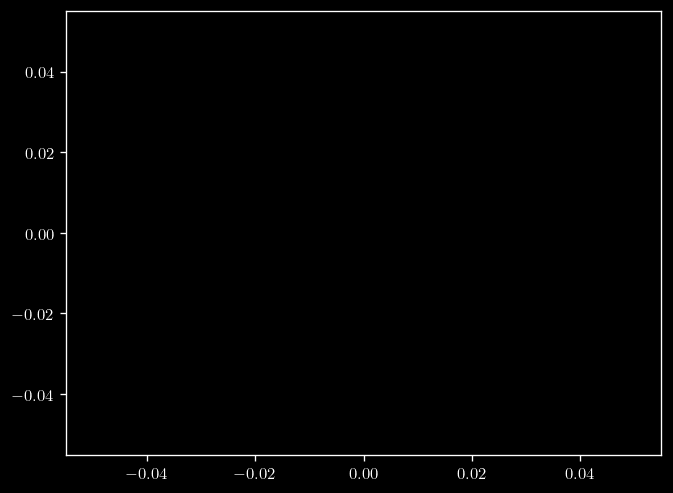

In [76]:
plt.plot([],[])  # Fixes some weird matplotlib bug with styles not being applied until after the second plot

In [77]:
plt.rcParams['figure.dpi'] = 120
plt.style.use('dark_background')

# Mock dataset with extinction-based selection function

This notebook generates a mock dataset using a Plummer sphere as the dynamical model, applying a mock 3D dust map to assign stellar extinctions, and then cutting stars that are fainter than some apparent magnitude threshold. 

# Plummer sphere model

First, we sample points from a unit Plummer sphere.

The Plummer sphere is a spherically symmetric, self-gravitating system. It has density
$$
  \rho \left( r \right) = \frac{3}{4 \pi} \left( 1 + r^2 \right)^{-\frac{5}{2}} \, ,
$$
which generates the gravitational potential
$$
  \Phi \left( r \right) = -\left( 1 + r^2 \right)^{-\frac{1}{2}} \, .
$$
There exists a simple distribution function with isotropic velocities that renders the system stationary. Begin with the specific energy of an individual particle:
$$
  E = \frac{1}{2} v^2 + \Phi \, .
$$
Then, the distribution function
$$
  f \left( E \right) \propto
  \begin{cases}
    \left( -E \right)^{\frac{7}{2}} \, , & E < 0 \\
    0 \, , & E > 0
  \end{cases}
$$
reduces to the above density (after integrating over velocity) and is stationary, since it only depends on a conserved quantity: the energy. Note that because the energy is always negative, all the particles are on bound orbits.
$$
  p \left( E \right) \\
  p \left( E \mid r \right)
$$

$$
  p \left( r \right) \propto r^2 \rho \left( r \right) \\
  p \left( v \mid r \right) \propto v^2 \left[ \left( 1 + r^2 \right)^{-\frac{1}{2}} + \frac{1}{2} v^2 \right]^{\frac{7}{2}}
$$

In [78]:
dist_fn = PlummerSphere()

rng = np.random.default_rng(42) # Fixed seed for reproducibility

r_max = 16.0  # maximum radius to sample

# Selection function (3D dust map)

We will apply a selection function to the dataset, based on a 3D dust map. We will begin by assigning every star an absolute magnitude from an arbitrary distribution. We will calculate the extinction to each star based on its position, and then apply a sharp cut on apparent magnitude.

We generate a mock 3D dust map using a Gaussian process with a specified power-law index. Specifically, we assume that the logarithm of the dust density is a Gaussian process.

In [79]:
def gen_gaussian_process(
    shape,                 # (X, Y, Z)
    power_law_index=-3.0,  # alpha in P(k) ∝ k^alpha
    field_variance=1.0,    # target variance of the field
    mean=0.0,              # target mean of the field
    rng=None
):
    """
    Pipeline:
      1) real white noise in real space
      2) FFT to k-space
      3) multiply by spectral envelope A(k) ∝ k^{alpha/2}
      4) inverse FFT to real space
      5) rescale to target variance and set mean
    """
    rng = np.random.default_rng() if rng is None else rng
    n_x, n_y, n_z = shape

    # 1) Real white noise (mean 0, var 1)
    xi = rng.standard_normal(shape)

    # 2) FFT to k-space (Hermitian symmetry guaranteed because xi is real)
    Xi = np.fft.fftn(xi)

    # 3) Build isotropic k grid and spectral envelope
    kx, ky, kz = np.meshgrid(
        np.fft.fftfreq(n_x, d=1.0),
        np.fft.fftfreq(n_y, d=1.0),
        np.fft.fftfreq(n_z, d=1.0),
        indexing="ij"
    )
    k = np.sqrt(kx**2 + ky**2 + kz**2)

    # Amplitude envelope A(k) so that power ∝ k^alpha  ⇒ |A|^2 ∝ k^alpha  ⇒ A ∝ k^{alpha/2}
    A = np.zeros_like(k, dtype=float)
    mask = (k > 0)
    A[mask] = k[mask]**(0.5 * power_law_index)

    # Zero out DC in the shaped random part
    A[0, 0, 0] = 0.0

    # Apply envelope
    F = A * Xi

    # 4) Back to real space
    f = np.fft.ifftn(F).real

    # 5a) Rescale to target variance (around zero)
    f *= np.sqrt(field_variance / f.var())

    # 5b) Set the mean
    f += mean

    return f


In [80]:
def gen_field_interpolator(field, extent, method='linear', fill_value=0.):
    """
    Generate an interpolator for a 3D field defined on a regular grid.

    Parameters
    ----------
    field : ndarray
        3D array of shape (Nx, Ny, Nz) representing the field values on a regular grid.
    extent : list of tuples
        [(x_min, x_max), (y_min, y_max), (z_min, z_max)] defining the physical extent of the grid.
    method : str, optional
        Interpolation method, one of 'linear', 'nearest', 'slinear', 'cubic', 'quintic' or
        'pchip'. Default is 'linear'.
    fill_value : float, optional
        Value to use for points outside the interpolation domain. Default is 0.0.

    Returns
    -------
    interpolator : function
        A function that takes an array of shape (M, 3) with (x, y, z) coordinates and returns
        the interpolated field values at those points.
    """

    from scipy.interpolate import RegularGridInterpolator

    (x_min, x_max), (y_min, y_max), (z_min, z_max) = extent
    n_x, n_y, n_z = field.shape

    # Create grid points
    x = np.linspace(x_min, x_max, n_x)
    y = np.linspace(y_min, y_max, n_y)
    z = np.linspace(z_min, z_max, n_z)

    # Create the interpolator
    interpolator = RegularGridInterpolator(
        (x, y, z),
        field,
        bounds_error=False,
        fill_value=fill_value,
        method=method
    )

    return interpolator

In [81]:
def integrate_field_radially(field_interpolator, xyz, n_steps=128):
    """
    Integrates a field radially out to the locations (x,y,z), taking
    a given number of steps along each ray.
    """

    r_max = np.linalg.norm(xyz, axis=1)
    xyz_unit = xyz / r_max[:,None]
    dr = r_max / n_steps

    xyz_current = np.zeros_like(xyz)
    integral = np.zeros(xyz.shape[0], dtype='f8')
    
    from tqdm.auto import tqdm

    for i in tqdm(range(n_steps)):
        xyz_current = xyz_unit * dr[:,None] * (i+0.5)
        integral += dr * field_interpolator(xyz_current)
    
    return integral

In [82]:
def gen_mock_dust_map(
    extent,
    n_modes,
    power_law_index=-3.0,
    mean_ln_density=-1.0,
    ln_density_variance=1.0,
    n_integration_steps=256,
    rng=None
):
    """
    Generates a mock dust map by creating a Gaussian random field
    with the specified properties.

    Parameters
    ----------
    extent : list of tuples
        [(x_min, x_max), (y_min, y_max), (z_min, z_max)] defining the physical extent of the grid.
    n_modes : tuple of ints
        Number of Fourier modes in each dimension (Nx, Ny, Nz).
    power_law_index : float, optional
        Power-law index for the power spectrum of the log density field. Default is -3.0.
    mean_ln_density : float, optional
        Mean of the log density field. Default is -1.0.
    ln_density_variance : float, optional
        Variance of the log density field. Default is 1.0.
    n_integration_steps : int, optional
        Number of steps to use in the radial integration. Default is 256.
    rng : np.random.Generator, optional
        Random number generator for reproducibility. If None (the default), a new generator is created.
    
    Returns
    -------
    density_interpolator : function
        Interpolator for the 3D density field.
    integrated_dust_interpolator : function
        Interpolator for the integrated dust map (also 3D).
    """

    if rng is None:
        rng = np.random.default_rng()

    # Create a Gaussian random field representing the log density
    print('Generating Gaussian random field for ln(density)...')
    ln_density = gen_gaussian_process(
        shape=n_modes,
        power_law_index=power_law_index,
        field_variance=ln_density_variance,
        mean=mean_ln_density,
        rng=rng
    )

    # Create interpolator for the (linear) density field
    print('Interpolating density field...')
    density_interpolator = gen_field_interpolator(
        np.exp(ln_density),
        extent=extent,
        method='linear',
    )

    # Integrate the field to create the integrated dust map
    # First, create (x,y,z) grid at which to evaluate the integrated map
    print('Integrating density field radially...')
    img_shape = [3*n for n in n_modes]
    xyz_grid = np.stack(np.meshgrid(*[
        np.linspace(x0,x1,s) for (x0,x1),s in zip(extent, img_shape)
    ], indexing='ij'), axis=-1)  # shape (Nx, Ny, Nz, 3)
    xyz_grid.shape = (-1, 3)  # shape (N, 3)
    integrated_dust_map = integrate_field_radially(
        density_interpolator,
        xyz_grid,
        n_steps=n_integration_steps
    )
    integrated_dust_map.shape = img_shape

    # Create interpolator for the integrated dust map
    print('Interpolating integrated dust map...')
    integrated_dust_interpolator = gen_field_interpolator(
        integrated_dust_map,
        extent=extent,
        method='linear',
    )

    # Return both interpolators
    return density_interpolator, integrated_dust_interpolator

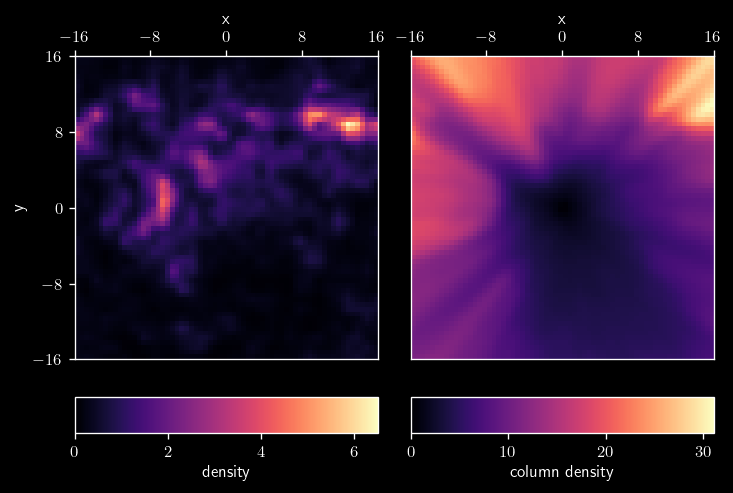

In [ ]:
extent = [(-r_max,r_max)]*3 # Physical extent of the dust map
n_modes = (32, 32, 32)      # Number of Fourier modes in each dimension

rho_dust_interp, integrated_dust_interp = gen_mock_dust_map(
    extent=extent,
    n_modes=n_modes,
    n_integration_steps=1024,
    rng=rng
)

img_shape = [2*n for n in n_modes[:2]]
xyz_grid = np.array(np.meshgrid(
    np.linspace(extent[0][0], extent[0][1], img_shape[0]),
    np.linspace(extent[1][0], extent[1][1], img_shape[1]),
    np.zeros(1),
    indexing='ij'
)).reshape(3, -1).T  # shape (N, 3)

fig,ax_arr = plt.subplots(
    2, 2,
    figsize=(6,4),
    height_ratios=[1,0.1],
    constrained_layout=True
)

# Left panel: density map
ax = ax_arr[0,0]
im = ax.imshow(
    rho_dust_interp(xyz_grid).reshape(img_shape),
    origin='lower',
    aspect='equal',
    extent=extent[0]+extent[1],
    cmap='magma',
    vmin=0.
)
fig.colorbar(
    im,
    cax=ax_arr[1,0],
    label='density',
    orientation='horizontal'
)
ax.set_xlabel('x')
ax.set_ylabel('y')
# Put x-axis ticks and label on top
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticks_position('top')
# Tick locators
ax.xaxis.set_major_locator(MaxNLocator(4))
ax.yaxis.set_major_locator(MaxNLocator(4))

# Right panel: integrated dust map
ax = ax_arr[0,1]
im = ax.imshow(
    integrated_dust_interp(xyz_grid).reshape(img_shape),
    origin='lower',
    aspect='equal',
    extent=extent[0]+extent[1],
    cmap='magma',
    vmin=0.
)
fig.colorbar(
    im,
    cax=ax_arr[1,1],
    label='column density',
    orientation='horizontal'
)
ax.set_xlabel('x')
# Put x-axis ticks and label on top
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticks_position('top')
# Tick locators
ax.xaxis.set_major_locator(MaxNLocator(4))
ax.set_yticks([]) # Get rid of y-axis ticks

plt.show()

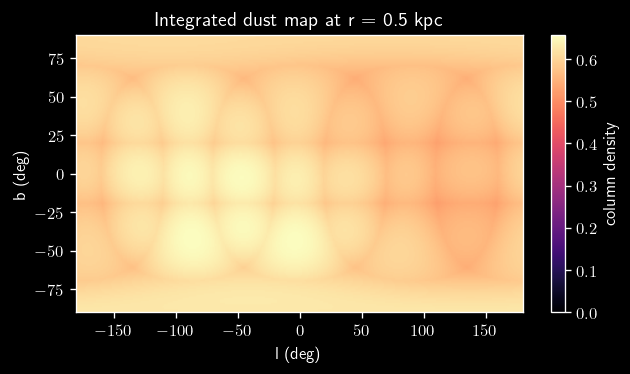

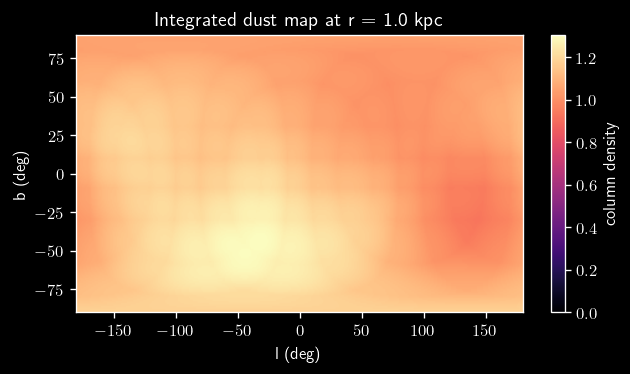

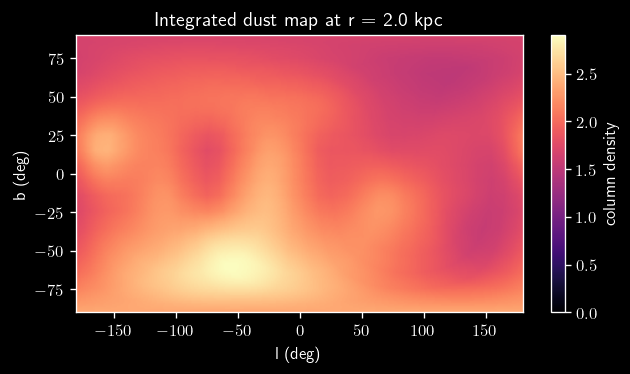

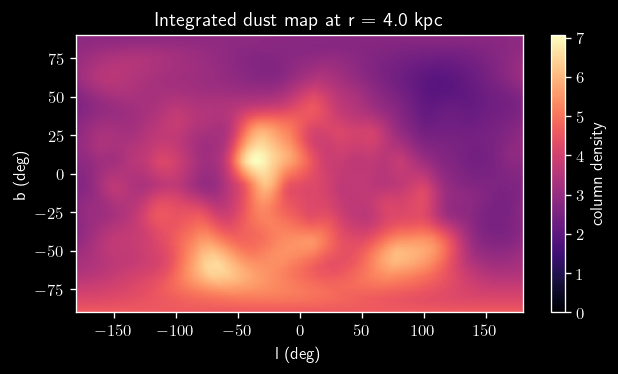

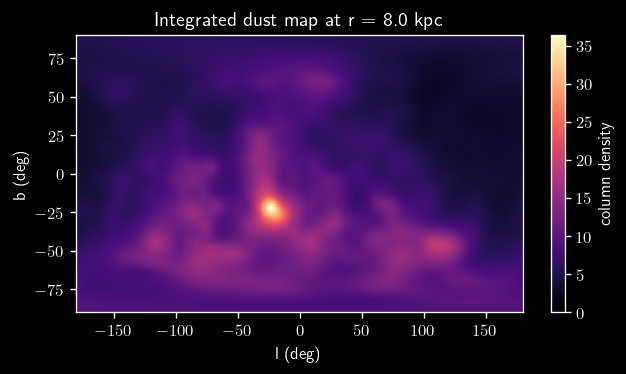

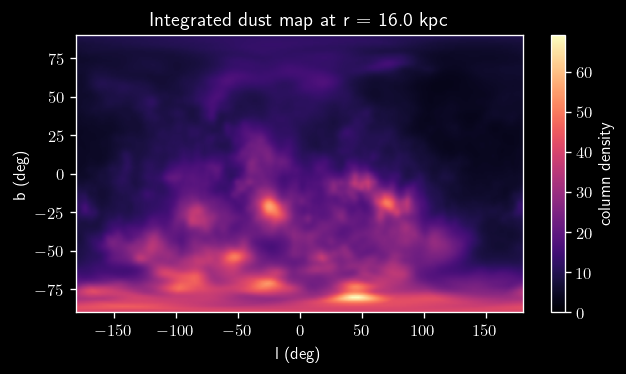

In [91]:
# Plot Cartesian sky projections of distance slices of integrated dust map

r_vals = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]  # kpc

l_vals = np.radians(np.linspace(-180, 180.01, 360))
b_vals = np.radians(np.linspace(-90, 90.01, 180))
l,b = np.meshgrid(l_vals, b_vals, indexing='ij')

# Points on unit sphere
xyz_unit = np.stack([
    np.cos(b) * np.cos(l),
    np.cos(b) * np.sin(l),
    np.sin(b)
], axis=-1)  # shape (N_l, N_b, 3)
xyz_unit.shape = (-1, 3)  # shape (N_l*N_b, 3)

for r in r_vals:
    img = integrated_dust_interp(xyz_unit * r)
    img.shape = l.shape

    plt.figure(figsize=(6,3))
    plt.imshow(
        img.T,
        origin='lower',
        extent=[-180,180,-90,90],
        cmap='magma',
        aspect='auto',
        vmin=0
    )
    plt.colorbar(label='column density')
    plt.title(f'Integrated dust map at r = {r:.1f} kpc')
    plt.xlabel('l (deg)')
    plt.ylabel('b (deg)')
    plt.show()

# Draw stars from Plummer sphere DF

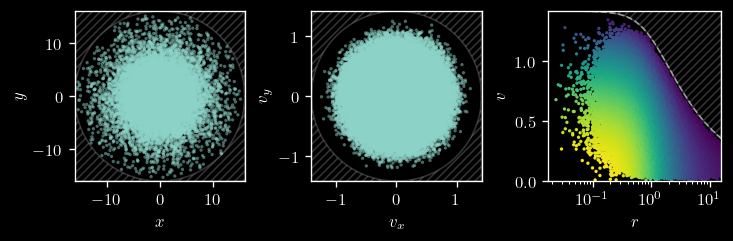

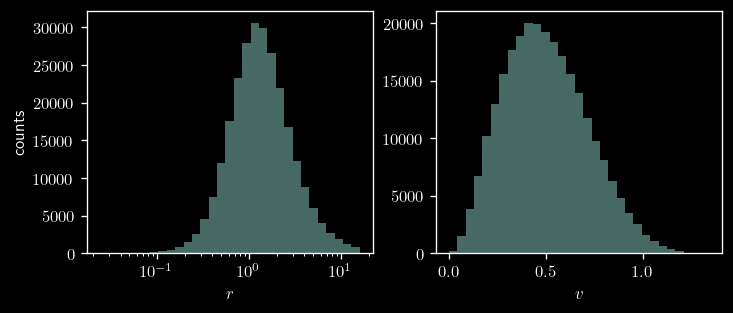

In [85]:
n_stars = 1024*256 # Number of stars to sample

x_samp,v_samp = dist_fn.sample_df(n_stars, r_max=r_max, rng=rng)

fig,ax_arr = plt.subplots(1, 3, figsize=(6,1.9), constrained_layout=True)

# (x,y) projection
ax = ax_arr[0]
ax.scatter(
    x_samp[:,0], x_samp[:,1],
    s=4, alpha=0.5, edgecolors='none'
)
ax.set_xlim(-r_max,r_max)
ax.set_ylim(-r_max,r_max)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

# Hatch region beyond r_max in the (x,y) plane, using
# two fill_between calls to get a circular hatched region
x = np.linspace(-r_max, r_max, 256)
y_pos = np.sqrt(r_max**2 - x**2)
ax.fill_between(
    x, y_pos, r_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.fill_between(
    x, -r_max, -y_pos,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)

# (vx,vy) projection
ax = ax_arr[1]
ax.scatter(
    v_samp[:,0], v_samp[:,1],
    s=4, alpha=0.5, edgecolors='none'
)
v_max = np.sqrt(2)
ax.set_xlim(-v_max,v_max)
ax.set_ylim(-v_max,v_max)
ax.set_aspect('equal')
ax.set_xlabel('$v_x$')
ax.set_ylabel('$v_y$')

# Hatch region above escape velocity (v_esc = sqrt(2))
# This will be everything beyond a radius of sqrt(2)
# in the (vx,vy) plane
vx = np.linspace(-v_max, v_max, 256)
vy_pos = np.sqrt(v_max**2 - vx**2)
ax.fill_between(
    vx, vy_pos, v_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.fill_between(
    vx, -v_max, -vy_pos,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)

# (r,v) projection
ax = ax_arr[2]
r = np.linalg.norm(x_samp, axis=1)
v = np.linalg.norm(v_samp, axis=1)
ax.scatter(
    r, v,
    c=-dist_fn.energy(x_samp, v_samp),  # color by energy
    # norm=LogNorm(),
    s=4, alpha=1, edgecolors='none'
)
ax.set_xscale('log')
ax.set_xlim(right=r_max)
# ax.set_ylim(0,v_max)
# ax.set_aspect('equal')
ax.set_xlabel('$r$')
ax.set_ylabel('$v$')

# Plot escape velocity curve
rlim = ax.get_xlim()
r_plot = np.logspace(np.log10(rlim[0]), np.log10(rlim[1]), 256)
v_esc = np.sqrt(-2*dist_fn.phi(r_plot))
ax.plot(r_plot, v_esc, 'w--', lw=1, alpha=0.5)
# Fill region above escape velocity with hatching
ax.fill_between(
    r_plot, v_esc, v_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.set_xlim(rlim)
ax.set_ylim(0,v_max)

plt.show()

# Histograms of r and v
fig,ax_arr = plt.subplots(1, 2, figsize=(6,2.5), constrained_layout=True)

ax = ax_arr[0]
r = np.linalg.norm(x_samp, axis=1)
r_grid = np.logspace(np.log10(np.min(r)), np.log10(r_max), 32)
ax.hist(r, bins=r_grid, density=False, histtype='stepfilled', alpha=0.5)
# ax.plot(r_grid, dist_fn.pdf_r(r_grid), 'k-', lw=1)
ax.set_xscale('log')
ax.set_xlabel('$r$')
ax.set_ylabel('counts')

ax = ax_arr[1]
v = np.linalg.norm(v_samp, axis=1)
v_grid = np.linspace(0, np.max(v), 32)
ax.hist(v, bins=v_grid, density=False, histtype='stepfilled', alpha=0.5)
ax.set_xlabel('$v$')
# ax.set_ylabel('counts')

plt.show()

# Apply selection function to mock stars

We draw the absolute magnitude of each star from a Gaussian distribution, and then look up the extinction (based on the integrated dust density at the star's position), allowing us to calculate the star's apparent magnitude. We apply a sharp cut at a specified limiting magnitude.

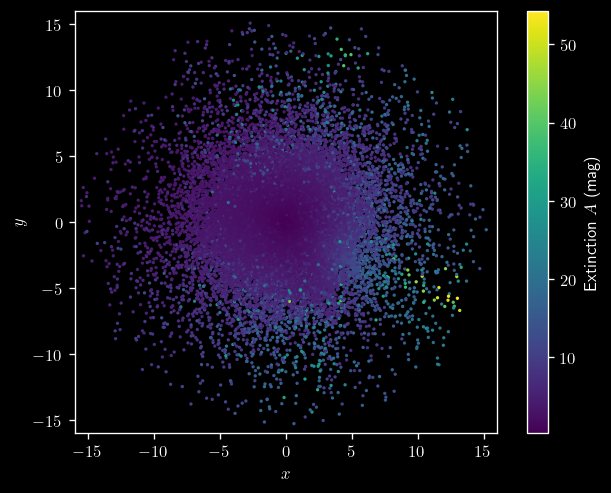

In [86]:
# Draw absolute magnitude for each star
M = rng.normal(5.0, 2.0, size=len(x_samp))

# Integrate dust density along each line of sight
A = integrated_dust_interp(x_samp)

# Calculate distance modulus and apparent magnitude
dm = 5 * np.log10(r/0.01) # distance modulus (assuming r is in kpc)
m = M + dm + A # apparent magnitude

# Plot (x,y) projection of all stars with extinction
fig,ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
im = ax.scatter(
    x_samp[:,0], x_samp[:,1],
    c=A[:],
    s=4, edgecolors='none'
)
ax.set_xlim(-r_max,r_max)
ax.set_ylim(-r_max,r_max)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Extinction $A$ (mag)')
plt.show()

Number of stars with m < 18.0: 159294 (60.8%)


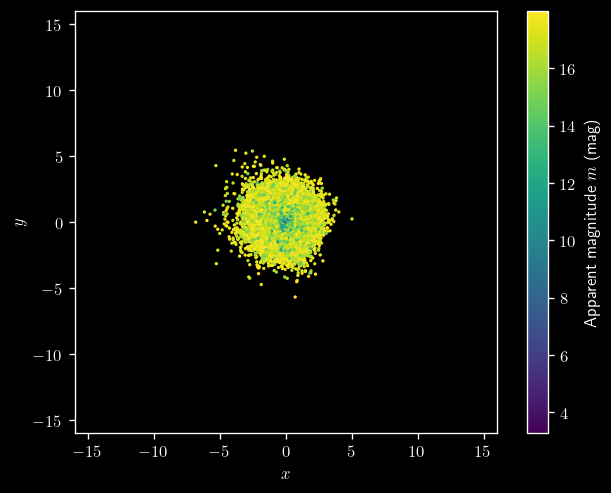

In [87]:
# Cut to m < m_max
m_max = 18.0
idx = (m < m_max)
print(f'Number of stars with m < {m_max}: {np.sum(idx)} ({np.mean(idx):.1%})')

# Plot (x,y) projection of stars that make the apparent magnitude cut
fig,ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
im = ax.scatter(
    x_samp[idx,0], x_samp[idx,1],
    c=m[idx],
    s=4, edgecolors='none'
)
ax.set_xlim(-r_max,r_max)
ax.set_ylim(-r_max,r_max)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Apparent magnitude $m$ (mag)')
plt.show()

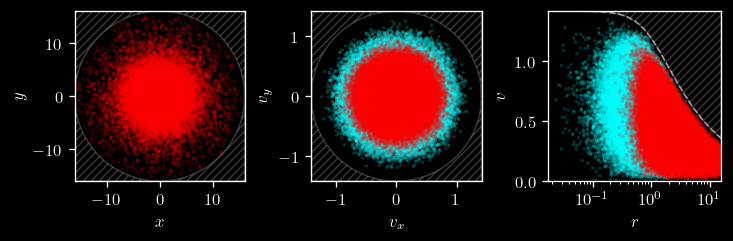

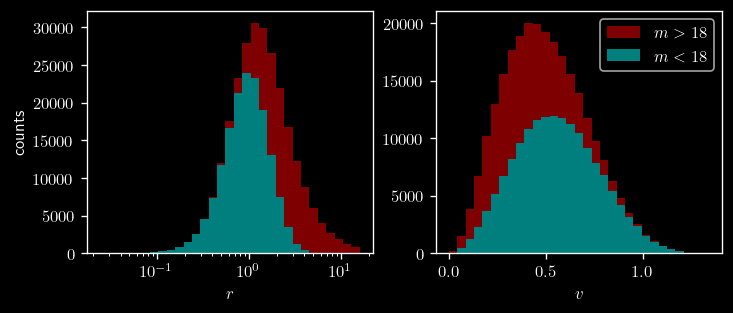

In [88]:
# Plot phase-space projections of stars that do and do not make the apparent magnitude cut

x_sel = x_samp[idx]
v_sel = v_samp[idx]
x_nosel = x_samp[~idx]
v_nosel = v_samp[~idx]

fig,ax_arr = plt.subplots(1, 3, figsize=(6,1.9), constrained_layout=True)

# (x,y) projection
ax = ax_arr[0]
ax.scatter(
    x_sel[:,0], x_sel[:,1],
    s=4, alpha=0.2, edgecolors='none',
    facecolors='cyan'
)
ax.scatter(
    x_nosel[:,0], x_nosel[:,1],
    s=4, alpha=0.2, edgecolors='none',
    facecolors='red'
)
ax.set_xlim(-r_max,r_max)
ax.set_ylim(-r_max,r_max)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

# Hatch region beyond r_max in the (x,y) plane, using
# two fill_between calls to get a circular hatched region
x = np.linspace(-r_max, r_max, 256)
y_pos = np.sqrt(r_max**2 - x**2)
ax.fill_between(
    x, y_pos, r_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.fill_between(
    x, -r_max, -y_pos,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)

# (vx,vy) projection
ax = ax_arr[1]
ax.scatter(
    v_sel[:,0], v_sel[:,1],
    s=4, alpha=0.2, edgecolors='none',
    facecolors='cyan'
)
ax.scatter(
    v_nosel[:,0], v_nosel[:,1],
    s=4, alpha=0.2, edgecolors='none',
    facecolors='red'
)
v_max = np.sqrt(2)
ax.set_xlim(-v_max,v_max)
ax.set_ylim(-v_max,v_max)
ax.set_aspect('equal')
ax.set_xlabel('$v_x$')
ax.set_ylabel('$v_y$')

# Hatch region above escape velocity (v_esc = sqrt(2))
# This will be everything beyond a radius of sqrt(2)
# in the (vx,vy) plane
vx = np.linspace(-v_max, v_max, 256)
vy_pos = np.sqrt(v_max**2 - vx**2)
ax.fill_between(
    vx, vy_pos, v_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.fill_between(
    vx, -v_max, -vy_pos,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)

# (r,v) projection
ax = ax_arr[2]
r = np.linalg.norm(x_samp, axis=1)
v = np.linalg.norm(v_samp, axis=1)
r_sel = r[idx]
v_sel = v[idx]
r_nosel = r[~idx]
v_nosel = v[~idx]
ax.scatter(
    r_sel, v_sel,
    s=4, alpha=0.2, edgecolors='none',
    facecolors='cyan'
)
ax.scatter(
    r_nosel, v_nosel,
    s=4, alpha=0.2, edgecolors='none',
    facecolors='red'
)
ax.set_xscale('log')
ax.set_xlim(right=r_max)
# ax.set_ylim(0,v_max)
# ax.set_aspect('equal')
ax.set_xlabel('$r$')
ax.set_ylabel('$v$')

# Plot escape velocity curve
rlim = ax.get_xlim()
r_plot = np.logspace(np.log10(rlim[0]), np.log10(rlim[1]), 256)
v_esc = np.sqrt(-2*dist_fn.phi(r_plot))
ax.plot(r_plot, v_esc, 'w--', lw=1, alpha=0.5)
# Fill region above escape velocity with hatching
ax.fill_between(
    r_plot, v_esc, v_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.set_xlim(rlim)
ax.set_ylim(0,v_max)

plt.show()

# Histograms of r and v. Stack selected and not selected.
fig,ax_arr = plt.subplots(1, 2, figsize=(6,2.5), constrained_layout=True)

ax = ax_arr[0]
r = np.linalg.norm(x_samp, axis=1)
r_grid = np.logspace(np.log10(np.min(r)), np.log10(r_max), 32)
ax.hist(
    [r_sel,r_nosel],
    stacked=True,
    bins=r_grid,
    density=False,
    histtype='stepfilled',
    color=['cyan','red'],
    alpha=0.5
)
# ax.plot(r_grid, dist_fn.pdf_r(r_grid), 'k-', lw=1)
ax.set_xscale('log')
ax.set_xlabel('$r$')
ax.set_ylabel('counts')

ax = ax_arr[1]
v = np.linalg.norm(v_samp, axis=1)
v_grid = np.linspace(0, np.max(v), 32)
ax.hist(
    [v_sel,v_nosel],
    stacked=True,
    bins=v_grid,
    density=False,
    histtype='stepfilled',
    color=['cyan','red'],
    alpha=0.5,
    label=[r'$m < 18$',r'$m > 18$']
)
ax.set_xlabel('$v$')
ax.legend()

plt.show()

In [89]:
# Output the selected and not selected samples to HDF5
import h5py

fn = 'plummer_sphere_selfn.h5'
with h5py.File(fn, 'w') as f:
    f.create_dataset('x_sel', data=x_sel)
    f.create_dataset('v_sel', data=v_sel)
    f.create_dataset('x_nosel', data=x_nosel)
    f.create_dataset('v_nosel', data=v_nosel)
    f.create_dataset('m_sel', data=m[idx])
    f.create_dataset('m_nosel', data=m[~idx])
    f.create_dataset('A_sel', data=A[idx])
    f.create_dataset('A_nosel', data=A[~idx])

! du -sh {fn}

# Pickle dust map interpolators
import pickle

fn = 'plummer_sphere_selfn_dustmaps.pkl'
with open(fn, 'wb') as f:
    pickle.dump({
        'rho_dust_interp': rho_dust_interp,
        'integrated_dust_interp': integrated_dust_interp
    }, f)

! du -sh {fn}

13M	plummer_sphere_selfn.h5
7.1M	plummer_sphere_selfn_dustmaps.pkl


In [90]:
# Test loading of dust map interpolators
with open(fn, 'rb') as f:
    dustmaps = pickle.load(f)
rho_dust_interp = dustmaps['rho_dust_interp']
integrated_dust_interp = dustmaps['integrated_dust_interp']